
<img src="https://reqlut2.s3.sa-east-1.amazonaws.com/reqlut-images/duoc/logo.png?v=87.8" width="180px"/>


In [1]:
import sys
import os

"""
En caso de que Python no encuentre en la ruta los otros directorios,
ejecutar esta configuración
"""

sys.path.append(os.path.abspath(".."))

# Evaluando el modelo construido

En este notebook se evalua y compara el modelo de Random Forest previamente entrenado para la predicción de depresión estudiantil.

La evaluación considera múltiples métricas de rendimiento y validación cruzada, con el objetivo de analizar la capacidad de generalización del modelo y comparar su desempeño en un contexto relacionado con salud mental.

Como los casos de depresión son un asunto muy sensible, se enfatizará especialmente en métricas como Recall y F1-score, debido a la importancia de identificar correctamente posibles casos de depresión y reducir falsos negativos.

In [3]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import (
    train_test_split,
    cross_validate
)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)
from src.carga_csv import cargar_csv

Primeramente se cargarán tanto los datos como el modelo construidos anteriormente en la fase 2 

In [6]:
# Dataset de entrenamiento
train_df = cargar_csv(
    r"../data/processed/Student_Depression_Dataset_Train.csv"
)

# Dataset de prueba
test_df = cargar_csv(
    r"../data/processed/Student_Depression_Dataset_Test.csv"
)

# Variables predictoras y objetivo
X_train = train_df.drop(columns=["Depression"])
y_train = train_df["Depression"]

X_test = test_df.drop(columns=["Depression"])
y_test = test_df["Depression"]

# Modelo
try:
    model_rf = joblib.load(
        r"../outputs/models/random_forest_model.pkl"
    )
except Exception as e:
    print(f"Error al cargar el modelo: {e}")
else:
    print("Modelo cargado correctamente.")

Modelo cargado correctamente.


#### Evaluación Inicial

Se generan predicciones utilizando el modelo sobre el conjunto de prueba.

Posteriormente, se calculan métricas fundamentales de clasificación para evaluar el desempeño inicial de cada modelo:

- Accuracy
- Precision
- Recall
- F1-score


In [7]:
y_pred_rf = model_rf.predict(X_test)

In [8]:
metrics_rf = {
    "Modelo": "Random Forest",
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "Precision": precision_score(y_test, y_pred_rf),
    "Recall": recall_score(y_test, y_pred_rf),
    "F1-Score": f1_score(y_test, y_pred_rf)
}

print("\n\n=== RANDOM FOREST ===\n")

for metric, value in metrics_rf.items():
    if metric != "Modelo":
        print(f"{metric}: {value:.4f}")

print("\n=== REPORTE DE CLASIFICACIÓN ===")
report_dict = classification_report(y_test, y_pred_rf, output_dict=True)
df_report = pd.DataFrame(report_dict).transpose()
df_report



=== RANDOM FOREST ===

Accuracy: 0.8429
Precision: 0.8521
Recall: 0.8855
F1-Score: 0.8685

=== REPORTE DE CLASIFICACIÓN ===


,precision,recall,f1-score,support
0,0.828663,0.782646,0.804998,2305.000000
1,0.852081,0.885548,0.868492,3259.000000
accuracy,0.842919,0.842919,0.842919,0.842919
macro avg,0.840372,0.834097,0.836745,5564.000000
weighted avg,0.842380,0.842919,0.842188,5564.000000


Información del modelo

In [9]:
RandomForest_df = pd.DataFrame([
    metrics_rf
])

print("\n=== Información Random Forest ===\n")
RandomForest_df


=== Información Random Forest ===



,Modelo,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.842919,0.852081,0.885548,0.868492


#### Validación Cruzada

Ahora, para una evaluación más robusta y reducir dependencia de una única división entrenamiento/prueba, aplicaremos una validación cruzada sobre el modelo.

Utilizando las mismas métricas de evaluación:

- Accuracy
- Precision
- Recall
- F1-score

Además de los valores promedio, se calcula la desviación estándar para analizar estabilidad y consistencia de los modelos.

$$CV = \frac{1}{k} \sum_{i=1}^{k} \text{Score}_i$$

In [10]:
# CONFIGURACIÓN MÉTRICAS CV
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

# VALIDACIÓN CRUZADA RF
cv_rf = cross_validate(
    model_rf,
    X,
    y,
    cv=5,
    scoring=scoring,
    n_jobs=-1
)

cv_results_rf = {
    "Modelo": "Random Forest",
    
    "Accuracy Mean": cv_rf["test_accuracy"].mean(),
    "Accuracy Std": cv_rf["test_accuracy"].std(),
    
    "Precision Mean": cv_rf["test_precision"].mean(),
    "Precision Std": cv_rf["test_precision"].std(),
    
    "Recall Mean": cv_rf["test_recall"].mean(),
    "Recall Std": cv_rf["test_recall"].std(),
    
    "F1 Mean": cv_rf["test_f1"].mean(),
    "F1 Std": cv_rf["test_f1"].std()
}

In [11]:
#Tabla comparativa de validación cruzada
cv_comparison_df = pd.DataFrame([
    cv_results_rf
])

print("=== VALIDACIÓN CRUZADA ===\n")
cv_comparison_df

=== VALIDACIÓN CRUZADA ===



,Modelo,Accuracy Mean,Accuracy Std,Precision Mean,Precision Std,Recall Mean,Recall Std,F1 Mean,F1 Std
0,Random Forest,0.843046,0.002689,0.854276,0.004449,0.882656,0.004137,0.868218,0.002087


#### Matrices de Confusión

Las matrices de confusión permiten visualizar de manera detallada el comportamiento de los modelos respecto a las clasificaciones correctas e incorrectas.

En este caso, los falsos negativos van a ser especialmente relevantes, ya que representan estudiantes con posible depresión clasificados incorrectamente como "No tiene depresión".

Por esta razón, además del accuracy, resulta fundamental analizar métricas como Recall y F1-score.

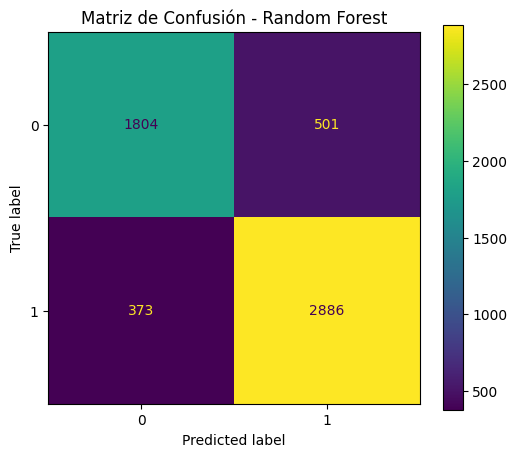

In [13]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
fig, ax = plt.subplots(figsize=(6, 5))
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(ax=ax)
plt.title("Matriz de Confusión - Random Forest")
plt.savefig("../outputs/plots/metrics/confusion_matrix_rf.png", bbox_inches="tight")
plt.show()

#### Otros gráficos
A modo de facilitar la comparación entre modelos, se visualizan las principales métricas de clasificación obtenidas sobre el conjunto de prueba (xtest).


### **Gráfico de barras de las métricas calculadas para ambos modelos**

               Accuracy  Precision    Recall  F1-Score
Modelo                                                
Random Forest  0.842919   0.852081  0.885548  0.868492


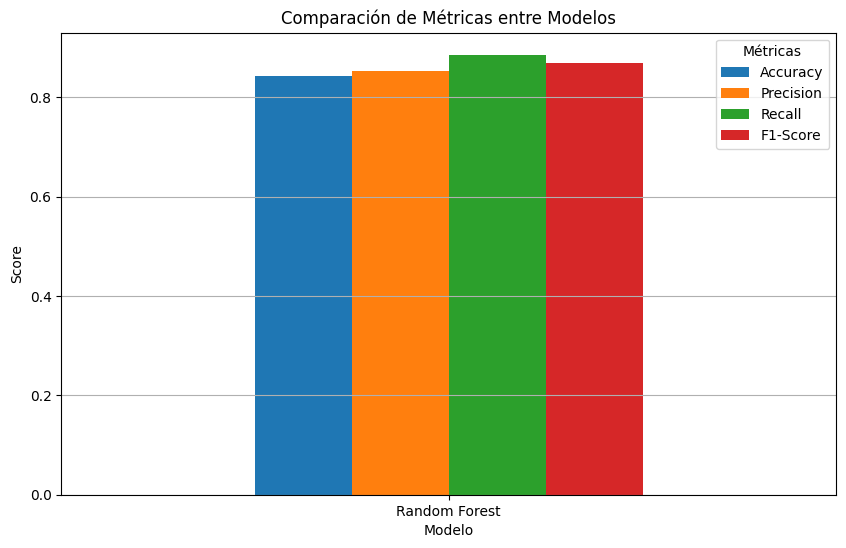

In [14]:
metrics_plot_df = RandomForest_df.set_index("Modelo")
print(metrics_plot_df)
fig, ax = plt.subplots(figsize=(10, 6))
metrics_plot_df.plot(kind="bar", ax=ax)
plt.title("Comparación de Métricas entre Modelos")
plt.ylabel("Score")
plt.xlabel("Modelo")
plt.xticks(rotation=0)
plt.legend(title="Métricas")
plt.grid(axis="y")
plt.savefig("../outputs/plots/metrics/metrics_comparison.png",bbox_inches="tight")
plt.show()

### **Gráfico de importancia de variables en Random Forest**

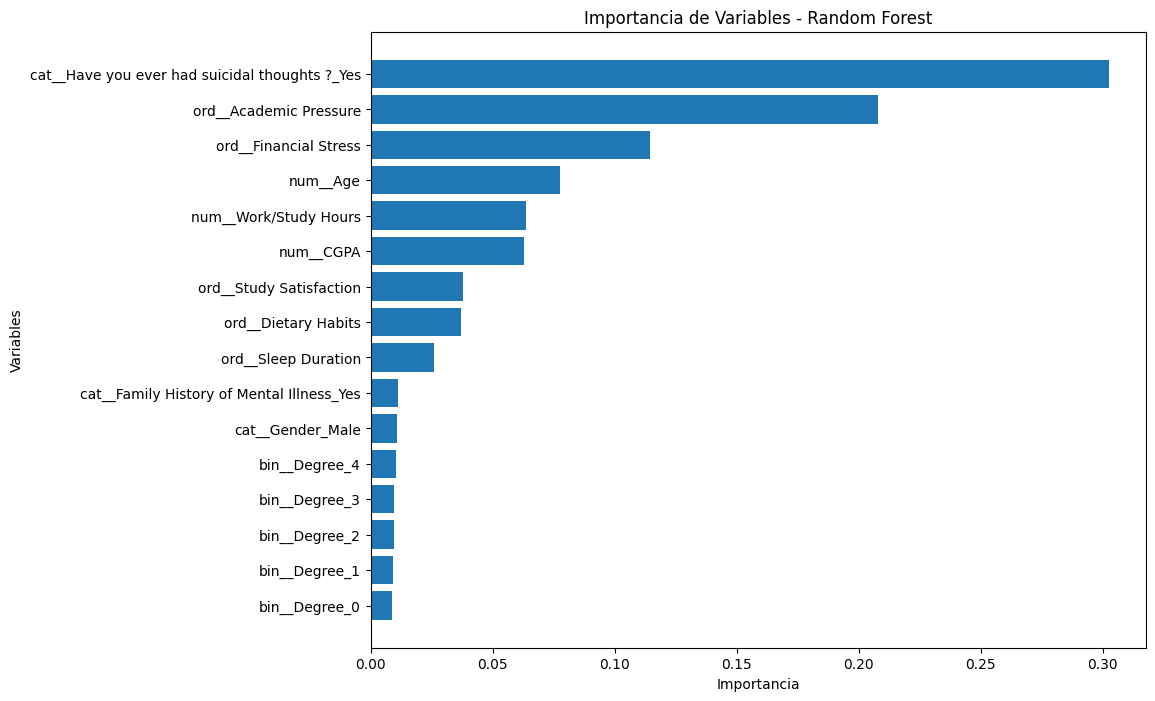

In [15]:
rf_model = model_rf.named_steps["model"] #Obtener el modelo interno del pipeline
importances = rf_model.feature_importances_ #Extraer importancias
feature_importance_df = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": importances
})
feature_importance_df = feature_importance_df.sort_values(by="Importancia", ascending=False)
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(
    feature_importance_df["Variable"],
    feature_importance_df["Importancia"]
)
ax.invert_yaxis()
plt.title("Importancia de Variables - Random Forest")
plt.xlabel("Importancia")
plt.ylabel("Variables")
plt.savefig("../outputs/plots/metrics/feature_importance_rf.png", bbox_inches="tight")
plt.show()